# Step 6 — Capacity Sizing

**目標**：評估系統在 peak / burst 場景下的負載能力。

模擬情境：某一個 loc_2 爆量到現在 peak 的 N 倍，其他 loc_2 維持現在的 peak。

In [1]:
# ===== 共用參數 =====
exec(open('../config/params.py').read())
# ==============================

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 150

df = pd.read_csv(DATA_PATH)
df['order_created_at'] = pd.to_datetime(df['order_created_at'], format=DATETIME_FORMAT)
df['hour'] = df['order_created_at'].dt.hour
df['date'] = df['order_created_at'].dt.date
print(f"Loaded {len(df):,} orders")


Loaded 30,000 orders


## 1. Current Capacity: Avg vs Peak

按 loc_2 × hour 計算每小時的 avg / peak 訂單數。

=== Current Capacity by loc_2 ===
  loc_2          Avg/hr  Peak/hr   Peak/Avg    Total
  --------------------------------------------------
  AREA-1           10.1       20        2.0x    7,399
  AREA-2            9.9       20        2.0x    7,277
  AREA-3           10.1       22        2.2x    7,373


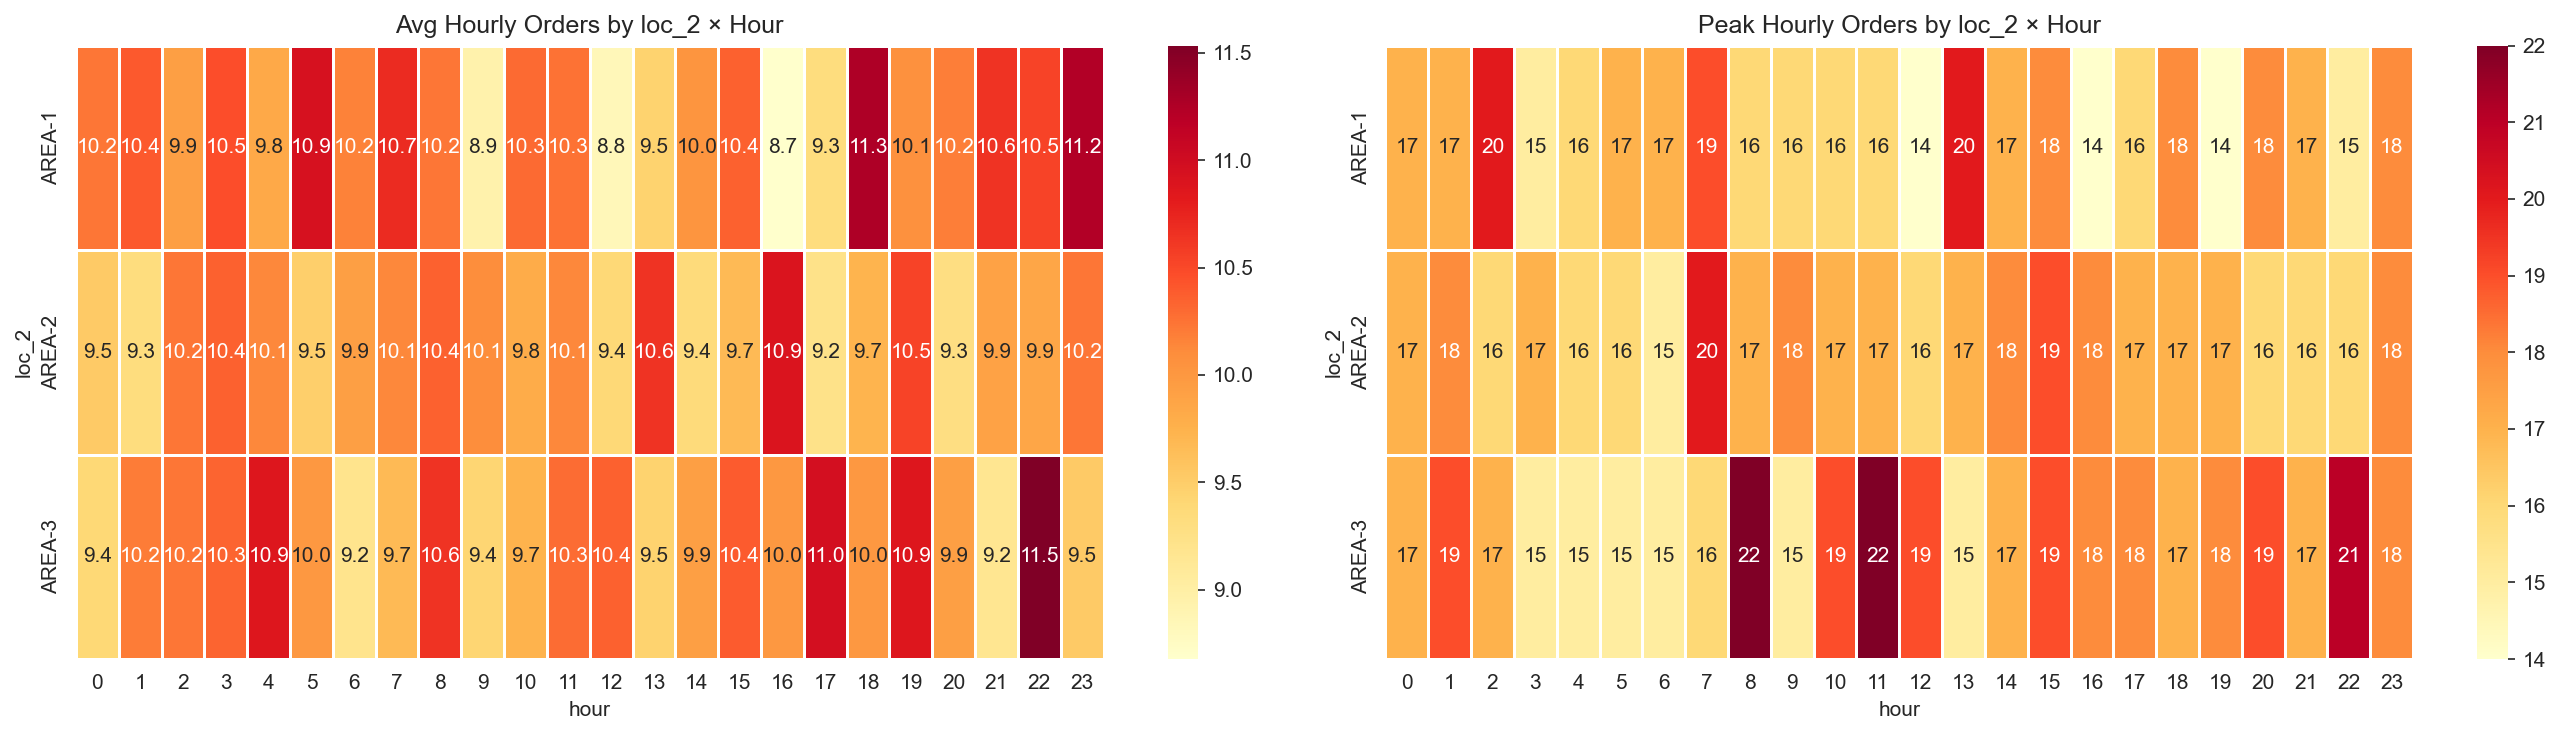

In [3]:
# Hourly order count by loc_2 × date × hour
loc2_data = df.dropna(subset=['loc_2'])
hourly = loc2_data.groupby(['loc_2', 'date', 'hour']).size().reset_index(name='order_count')

# Avg and Peak per loc_2 × hour
capacity = hourly.groupby(['loc_2', 'hour']).agg(
    avg=('order_count', 'mean'),
    peak=('order_count', 'max'),
    p95=('order_count', lambda x: x.quantile(0.95)),
).reset_index()

# Summary table: loc_2 level
loc2_summary = hourly.groupby('loc_2').agg(
    avg_hourly=('order_count', 'mean'),
    peak_hourly=('order_count', 'max'),
    total_orders=('order_count', 'sum'),
).reset_index()
loc2_summary['peak_to_avg'] = (loc2_summary['peak_hourly'] / loc2_summary['avg_hourly']).round(1)

print("=== Current Capacity by loc_2 ===")
print(f"  {'loc_2':<12} {'Avg/hr':>8} {'Peak/hr':>8} {'Peak/Avg':>10} {'Total':>8}")
print("  " + "-" * 50)
for _, row in loc2_summary.iterrows():
    print(f"  {row['loc_2']:<12} {row['avg_hourly']:>8.1f} {row['peak_hourly']:>8.0f} {row['peak_to_avg']:>10.1f}x {row['total_orders']:>8,}")

# Heatmaps: avg vs peak
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

avg_pivot = capacity.pivot_table(index='loc_2', columns='hour', values='avg', fill_value=0)
sns.heatmap(avg_pivot, cmap='YlOrRd', annot=True, fmt='.1f', ax=axes[0], linewidths=0.5)
axes[0].set_title('Avg Hourly Orders by loc_2 × Hour')

peak_pivot = capacity.pivot_table(index='loc_2', columns='hour', values='peak', fill_value=0)
sns.heatmap(peak_pivot, cmap='YlOrRd', annot=True, fmt='.0f', ax=axes[1], linewidths=0.5)
axes[1].set_title('Peak Hourly Orders by loc_2 × Hour')

plt.tight_layout()
plt.savefig(REPORTS_DIR / 'step6_current_capacity.png', dpi=150, bbox_inches='tight')
plt.show()


## 2. Burst Scenario Simulation

模擬：每個 loc_2 輪流爆量到 peak × `BURST_MULTIPLIER`，
其他 loc_2 維持 current peak。計算全系統 total load。

In [4]:
# Simulate burst scenarios
loc2_list = sorted(loc2_summary['loc_2'].unique())
peak_by_loc2 = loc2_summary.set_index('loc_2')['peak_hourly']

print(f"BURST_MULTIPLIER = {BURST_MULTIPLIER}x\n")

scenarios = []
for burst_loc in loc2_list:
    total_load = 0
    burst_load = 0
    for loc in loc2_list:
        if loc == burst_loc:
            load = peak_by_loc2[loc] * BURST_MULTIPLIER
            burst_load = load
        else:
            load = peak_by_loc2[loc]
        total_load += load
    
    # Also include loc_2=null orders at their peak
    null_peak = hourly[~hourly['loc_2'].isin(loc2_list)]['order_count'].max() if len(hourly) > len(loc2_data) else 0
    
    scenarios.append({
        'Burst Location': burst_loc,
        'Burst Load (orders/hr)': int(burst_load),
        'Other Locs Peak (orders/hr)': int(total_load - burst_load),
        'Total System Load (orders/hr)': int(total_load),
    })

scenario_df = pd.DataFrame(scenarios)

# Current baseline (all at peak)
all_peak = int(peak_by_loc2.sum())
print(f"Current all-peak load: {all_peak} orders/hr")
print(f"\n=== Burst Scenarios (one loc_2 at {BURST_MULTIPLIER}x peak, others at current peak) ===")
print(scenario_df.to_string(index=False))

# Ratio vs current
scenario_df['vs Current Peak'] = (scenario_df['Total System Load (orders/hr)'] / all_peak).round(1).astype(str) + 'x'
print(f"\nImpact vs current all-peak:")
for _, row in scenario_df.iterrows():
    print(f"  {row['Burst Location']} burst: {row['Total System Load (orders/hr)']} orders/hr ({row['vs Current Peak']})")


BURST_MULTIPLIER = 10x

Current all-peak load: 62 orders/hr

=== Burst Scenarios (one loc_2 at 10x peak, others at current peak) ===
Burst Location  Burst Load (orders/hr)  Other Locs Peak (orders/hr)  Total System Load (orders/hr)
        AREA-1                     200                           42                            242
        AREA-2                     200                           42                            242
        AREA-3                     220                           40                            260

Impact vs current all-peak:
  AREA-1 burst: 242 orders/hr (3.9x)
  AREA-2 burst: 242 orders/hr (3.9x)
  AREA-3 burst: 260 orders/hr (4.2x)


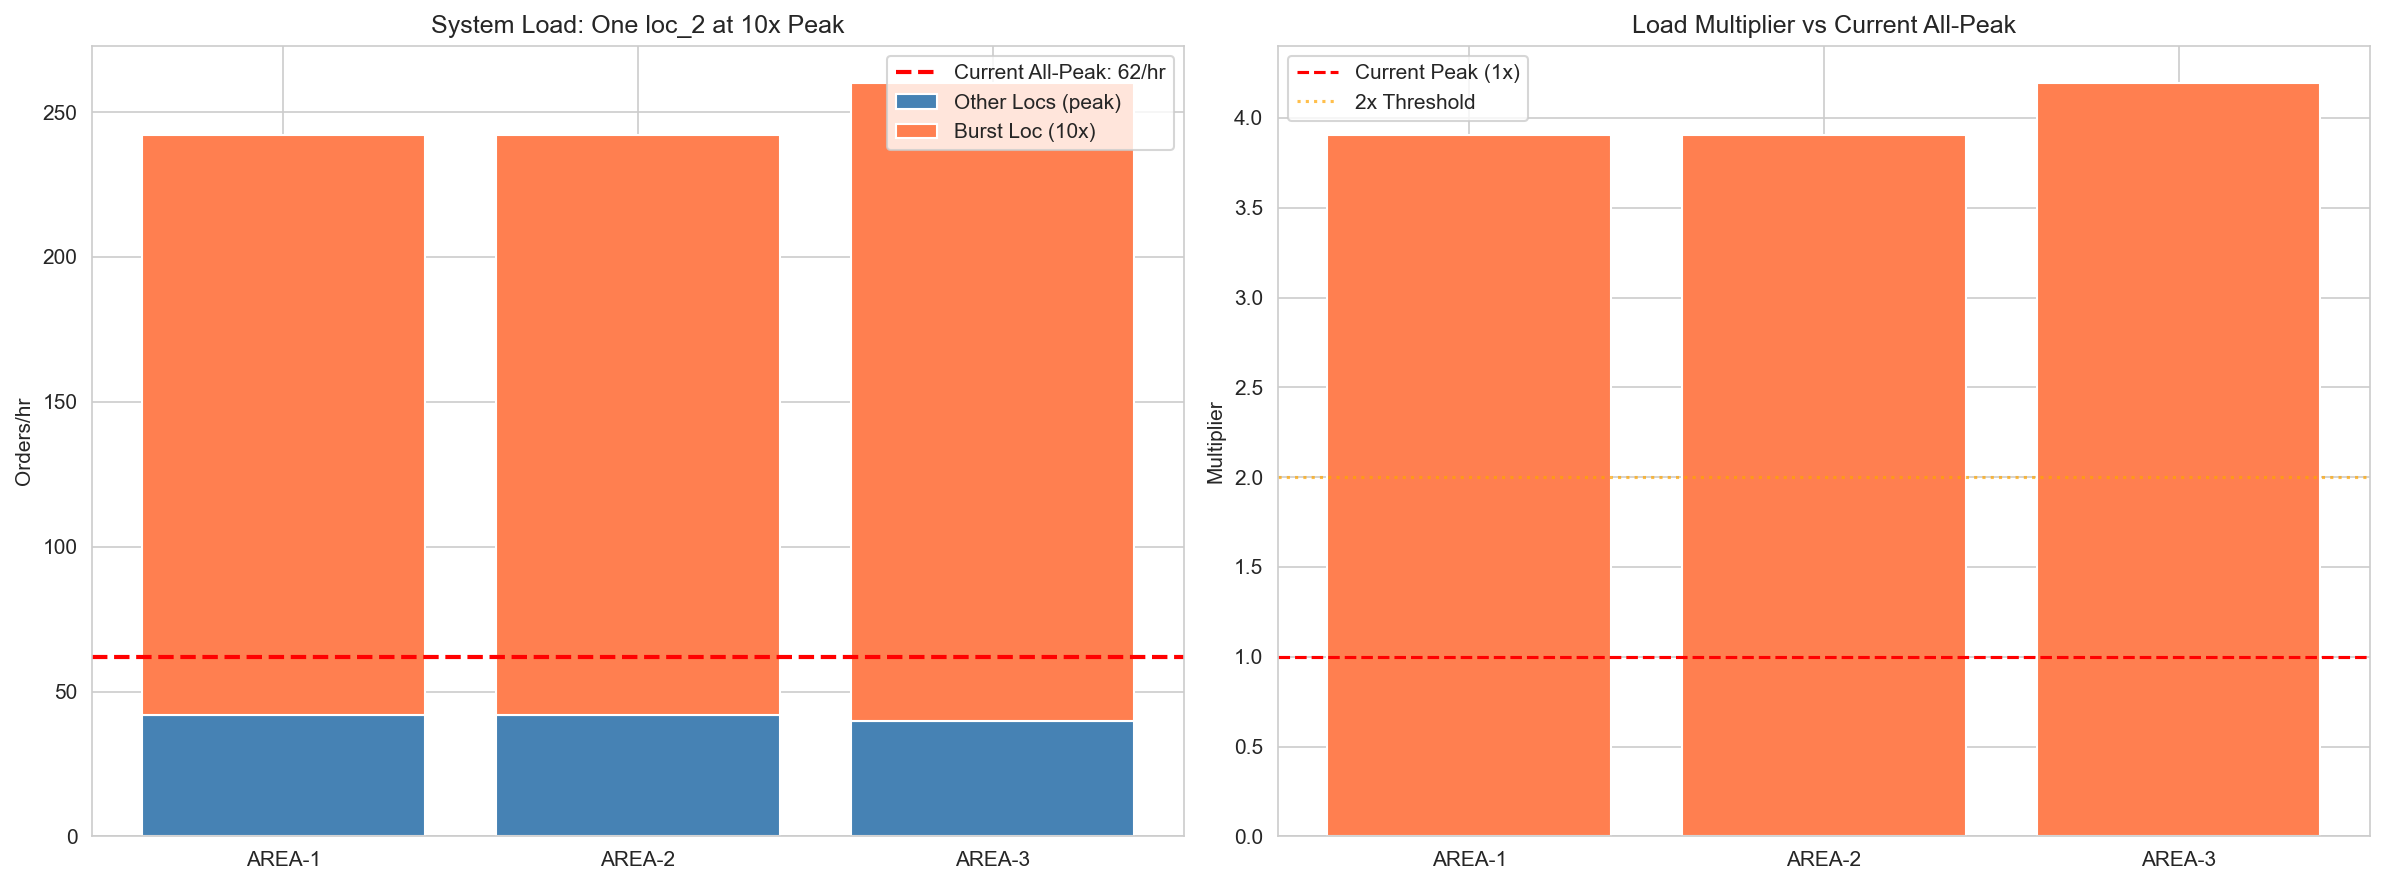

In [5]:
# Visualization: scenario comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: bar chart of total load per scenario
ax = axes[0]
x = range(len(scenario_df))
ax.bar(x, scenario_df['Other Locs Peak (orders/hr)'], label='Other Locs (peak)', color='steelblue')
ax.bar(x, scenario_df['Burst Load (orders/hr)'], 
       bottom=scenario_df['Other Locs Peak (orders/hr)'], label=f'Burst Loc ({BURST_MULTIPLIER}x)', color='coral')
ax.axhline(y=all_peak, color='red', linestyle='--', linewidth=2, label=f'Current All-Peak: {all_peak}/hr')
ax.set_xticks(list(x))
ax.set_xticklabels(scenario_df['Burst Location'])
ax.set_title(f'System Load: One loc_2 at {BURST_MULTIPLIER}x Peak')
ax.set_ylabel('Orders/hr')
ax.legend()

# Right: estimated duration impact
# Use the linear relationship from Step 3 (duration ≈ slope × file_count)
# More orders → more contention → potentially longer device_duration
# But queue is the main concern: more orders per hour → longer queue wait
avg_file_count = df['file_count'].median()
avg_per_order_seconds = df['total_duration_seconds'].median()

# Simple model: if system can handle X orders/hr, 
# each order takes avg_per_order_seconds of processing time
# With PARALLELISM threads, effective throughput = ?
# Actually, just show the load multiplier

ax = axes[1]
current_load = all_peak
burst_loads = scenario_df['Total System Load (orders/hr)'].values
multipliers = burst_loads / current_load

ax.bar(range(len(scenario_df)), multipliers, color=['coral' if m > 2 else 'steelblue' for m in multipliers])
ax.axhline(y=1, color='red', linestyle='--', label='Current Peak (1x)')
ax.axhline(y=2, color='orange', linestyle=':', alpha=0.7, label='2x Threshold')
ax.set_xticks(list(range(len(scenario_df))))
ax.set_xticklabels(scenario_df['Burst Location'])
ax.set_title('Load Multiplier vs Current All-Peak')
ax.set_ylabel('Multiplier')
ax.legend()

plt.tight_layout()
plt.savefig(REPORTS_DIR / 'step6_burst_scenarios.png', dpi=150)
plt.show()


## 3. Hourly Capacity Timeline

每小時的實際訂單量 vs burst 情境下的預估量。

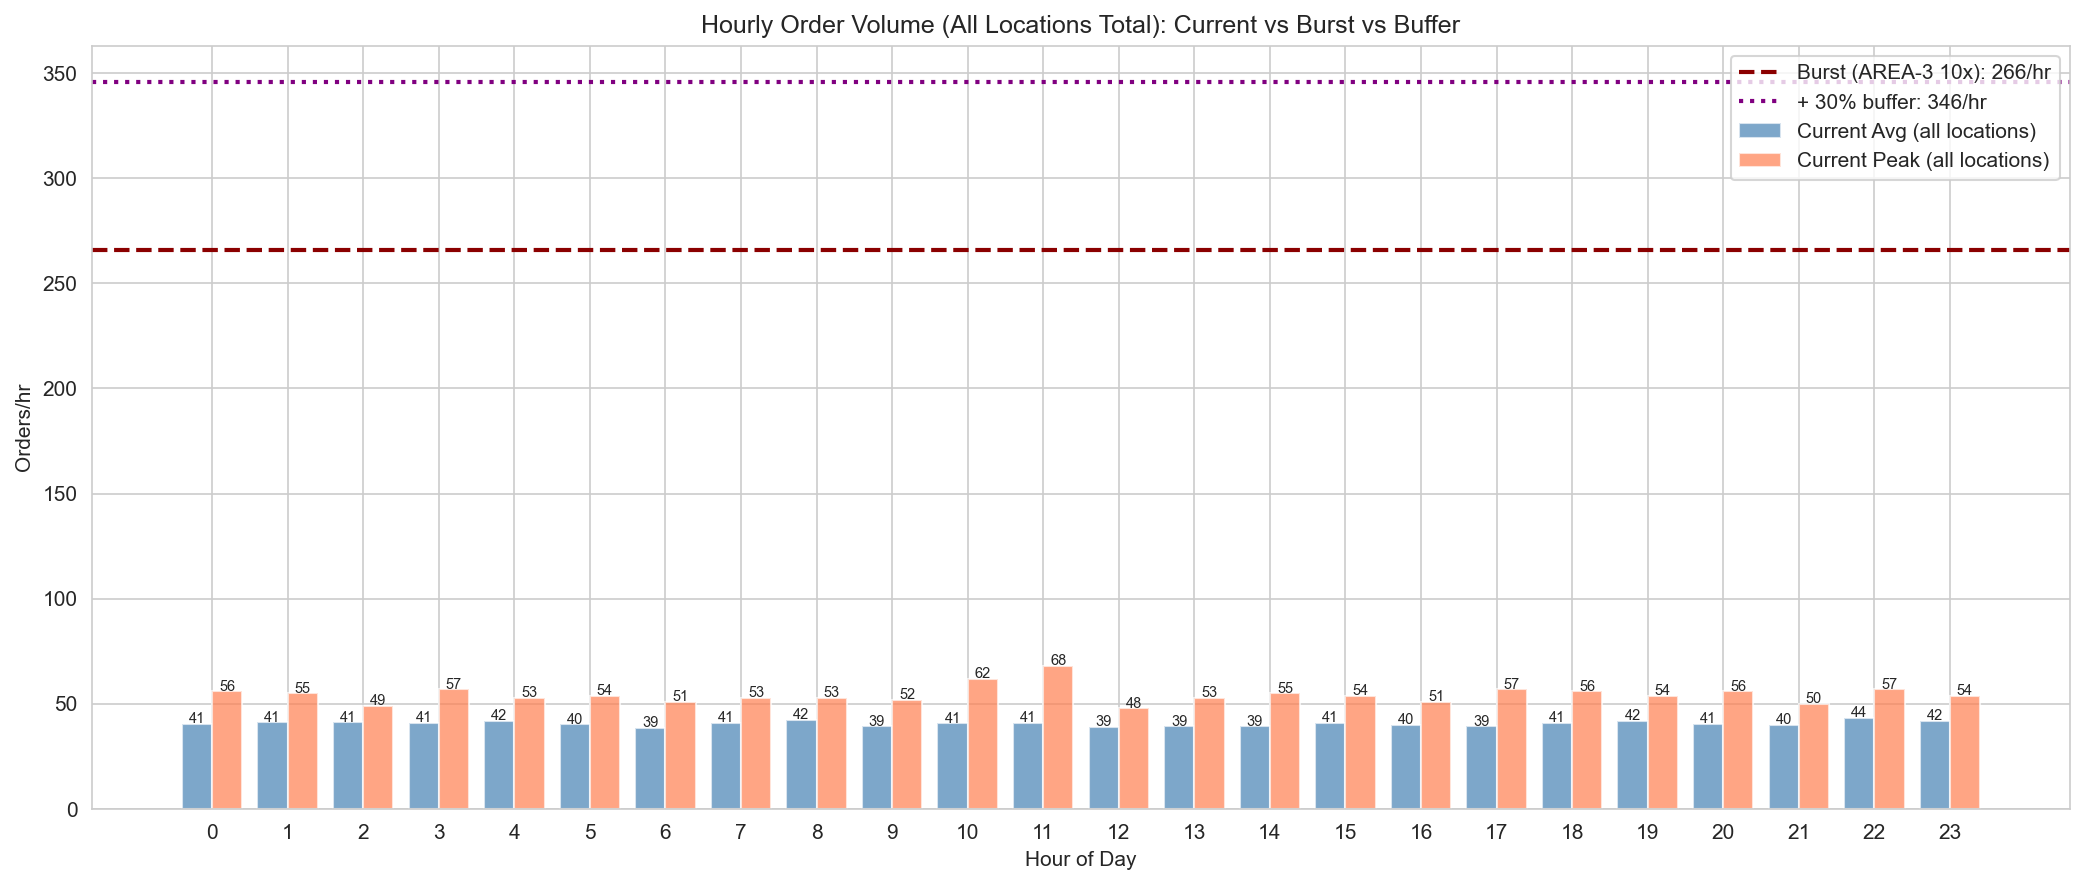

Current peak hour: 11:00 (68 orders)
Burst scenario (AREA-3 10x): 266 orders/hr
+ 30% buffer: 346 orders/hr


In [6]:
# Hourly timeline: current vs burst vs buffered
total_hourly = df.groupby(['date', 'hour']).size().reset_index(name='order_count')
hourly_stats = total_hourly.groupby('hour').agg(
    avg=('order_count', 'mean'),
    peak=('order_count', 'max'),
).reset_index()

busiest_loc = peak_by_loc2.idxmax()
busiest_peak = peak_by_loc2.max()
burst_delta = busiest_peak * (BURST_MULTIPLIER - 1)

fig, ax = plt.subplots(figsize=(14, 6))
bars_avg = ax.bar(hourly_stats['hour'] - 0.2, hourly_stats['avg'], width=0.4, 
                   label='Current Avg (all locations)', color='steelblue', alpha=0.7)
bars_peak = ax.bar(hourly_stats['hour'] + 0.2, hourly_stats['peak'], width=0.4, 
                    label='Current Peak (all locations)', color='coral', alpha=0.7)

# Number labels on bars
for bar in bars_avg:
    h = bar.get_height()
    if h > 0:
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.3, f'{h:.0f}', ha='center', fontsize=7)
for bar in bars_peak:
    h = bar.get_height()
    if h > 0:
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.3, f'{h:.0f}', ha='center', fontsize=7)

# Burst line
burst_level = hourly_stats['peak'].max() + burst_delta
ax.axhline(y=burst_level, color='darkred', linestyle='--', linewidth=2,
           label=f'Burst ({busiest_loc} {BURST_MULTIPLIER}x): {burst_level:.0f}/hr')

# Buffer line
buffered_level = burst_level * CAPACITY_BUFFER
ax.axhline(y=buffered_level, color='purple', linestyle=':', linewidth=2,
           label=f'+ {(CAPACITY_BUFFER-1)*100:.0f}% buffer: {buffered_level:.0f}/hr')

ax.set_title('Hourly Order Volume (All Locations Total): Current vs Burst vs Buffer')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Orders/hr')
ax.set_xticks(range(24))
ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'step6_hourly_capacity.png', dpi=150)
plt.show()

print(f"Current peak hour: {hourly_stats.loc[hourly_stats['peak'].idxmax(), 'hour']:.0f}:00 ({hourly_stats['peak'].max():.0f} orders)")
print(f"Burst scenario ({busiest_loc} {BURST_MULTIPLIER}x): {burst_level:.0f} orders/hr")
print(f"+ {(CAPACITY_BUFFER-1)*100:.0f}% buffer: {buffered_level:.0f} orders/hr")


## 4. Summary

In [7]:
# Export summary
summary = []
summary.append("=" * 60)
summary.append("Step 6 — Capacity Sizing")
summary.append("=" * 60)

summary.append(f"\n--- 參數 ---")
summary.append(f"BURST_MULTIPLIER = {BURST_MULTIPLIER}x  （模擬某 loc_2 爆量到 peak 的幾倍）")
summary.append(f"CAPACITY_BUFFER = {CAPACITY_BUFFER}x  （安全餘量，{(CAPACITY_BUFFER-1)*100:.0f}% buffer）")

summary.append(f"\n--- 計算邏輯 ---")
summary.append(f"  Peak 算法: burst_loc's peak × {BURST_MULTIPLIER} + 其他 loc_2's current peak")
summary.append(f"  Capacity 需求 = Peak × {CAPACITY_BUFFER} (buffer)")
summary.append(f"  例: {loc2_list[0]} burst = {int(peak_by_loc2[loc2_list[0]])} × {BURST_MULTIPLIER} "
               f"+ {' + '.join(f'{int(peak_by_loc2[l])}({l})' for l in loc2_list if l != loc2_list[0])}"
               f" = {scenario_df.iloc[0]['Total System Load (orders/hr)']} orders/hr")

summary.append(f"\n--- Current Capacity ---")
summary.append(f"  All-peak load: {all_peak} orders/hr  （所有 loc_2 同時 peak 的 total）")
for _, row in loc2_summary.iterrows():
    summary.append(f"  {row['loc_2']}: avg={row['avg_hourly']:.1f}/hr, peak={row['peak_hourly']:.0f}/hr")

summary.append(f"\n--- Burst Scenarios ---")
for _, row in scenario_df.iterrows():
    burst_val = row['Burst Load (orders/hr)']
    others_val = row['Other Locs Peak (orders/hr)']
    total = row['Total System Load (orders/hr)']
    buffered = int(total * CAPACITY_BUFFER)
    summary.append(f"  {row['Burst Location']} burst:")
    summary.append(f"    Peak = {burst_val} (burst) + {others_val} (others peak) = {total} orders/hr")
    summary.append(f"    × {CAPACITY_BUFFER} buffer = {buffered} orders/hr  ← capacity 需求")

summary.append(f"\n--- Capacity Planning ---")
max_burst = scenario_df['Total System Load (orders/hr)'].max()
max_buffered = int(max_burst * CAPACITY_BUFFER)
summary.append(f"  Worst-case burst: {max_burst} orders/hr")
summary.append(f"  × {CAPACITY_BUFFER} buffer = {max_buffered} orders/hr")
summary.append(f"  系統需能承受 {max_buffered} orders/hr 才能安全應對 {BURST_MULTIPLIER}x burst + {(CAPACITY_BUFFER-1)*100:.0f}% buffer")

with open(str(REPORTS_DIR / 'step6_summary.txt'), 'w') as f:
    f.write('\n'.join(summary))
print(f"Saved: reports/step6_summary.txt")
print('\n'.join(summary))


Saved: reports/step6_summary.txt
Step 6 — Capacity Sizing

--- 參數 ---
BURST_MULTIPLIER = 10x  （模擬某 loc_2 爆量到 peak 的幾倍）
CAPACITY_BUFFER = 1.3x  （安全餘量，30% buffer）

--- 計算邏輯 ---
  Peak 算法: burst_loc's peak × 10 + 其他 loc_2's current peak
  Capacity 需求 = Peak × 1.3 (buffer)
  例: AREA-1 burst = 20 × 10 + 20(AREA-2) + 22(AREA-3) = 242 orders/hr

--- Current Capacity ---
  All-peak load: 62 orders/hr  （所有 loc_2 同時 peak 的 total）
  AREA-1: avg=10.1/hr, peak=20/hr
  AREA-2: avg=9.9/hr, peak=20/hr
  AREA-3: avg=10.1/hr, peak=22/hr

--- Burst Scenarios ---
  AREA-1 burst:
    Peak = 200 (burst) + 42 (others peak) = 242 orders/hr
    × 1.3 buffer = 314 orders/hr  ← capacity 需求
  AREA-2 burst:
    Peak = 200 (burst) + 42 (others peak) = 242 orders/hr
    × 1.3 buffer = 314 orders/hr  ← capacity 需求
  AREA-3 burst:
    Peak = 220 (burst) + 40 (others peak) = 260 orders/hr
    × 1.3 buffer = 338 orders/hr  ← capacity 需求

--- Capacity Planning ---
  Worst-case burst: 260 orders/hr
  × 1.3 buffer = 338 or